# Wine Quality Prediction: Comparing Classification Models

**Objective:** Train and compare multiple classification models to predict wine quality from physicochemical properties (acidity, density, alcohol content, etc.), and identify which model is most suitable for deployment.

**Dataset:** UCI Machine Learning Repository — **Wine Quality (Red Wine)** dataset, 1,599 samples, 11 physicochemical input features, and a `quality` score (integer, 3–8) rated by wine tasters. This is the real, publicly available dataset (not synthetic).

**Tech stack:** Python, pandas, numpy, scikit-learn (RandomForestClassifier, SGDClassifier, SVC), seaborn, matplotlib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42


## 1. Load Dataset and Inspect Structure

In [2]:
df = pd.read_csv("winequality-red.csv")
print("Shape:", df.shape)
df.head()


Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print("Dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Dtypes:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate rows: 240


In [4]:
quality_counts = df["quality"].value_counts().sort_index()
print("Class distribution of quality scores:\n")
print(quality_counts)
print("\nAs percentage:\n")
print((quality_counts / len(df) * 100).round(2))


Class distribution of quality scores:

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

As percentage:

quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: count, dtype: float64


/tmp/ipykernel_103/2386661174.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, ax=ax, palette="Set2")


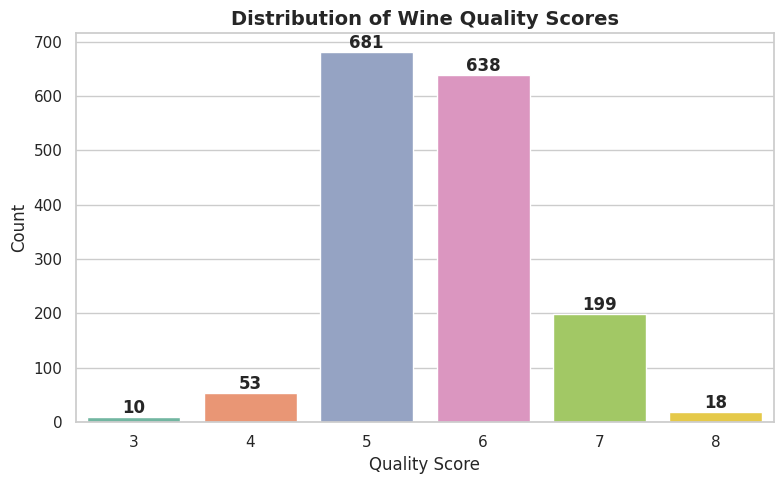

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x="quality", data=df, ax=ax, palette="Set2")
ax.set_title("Distribution of Wine Quality Scores", fontsize=14, fontweight="bold")
ax.set_xlabel("Quality Score")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()


**Observation:** The dataset has **1,599 rows, 11 numeric physicochemical features, and no missing values or duplicates** — a clean starting point. The `quality` target is a **6-level ordinal score (3–8)**, but the distribution is heavily skewed toward the middle: qualities **5 and 6 account for over 82% of all samples**, while the extremes (3, 4, 8) are rare — quality 3 has only 10 examples and quality 8 has only 18, out of 1,599. This immediately signals a significant class imbalance problem that we address explicitly in Section 3.

## 2. EDA: Feature Distributions and Correlation Heatmap

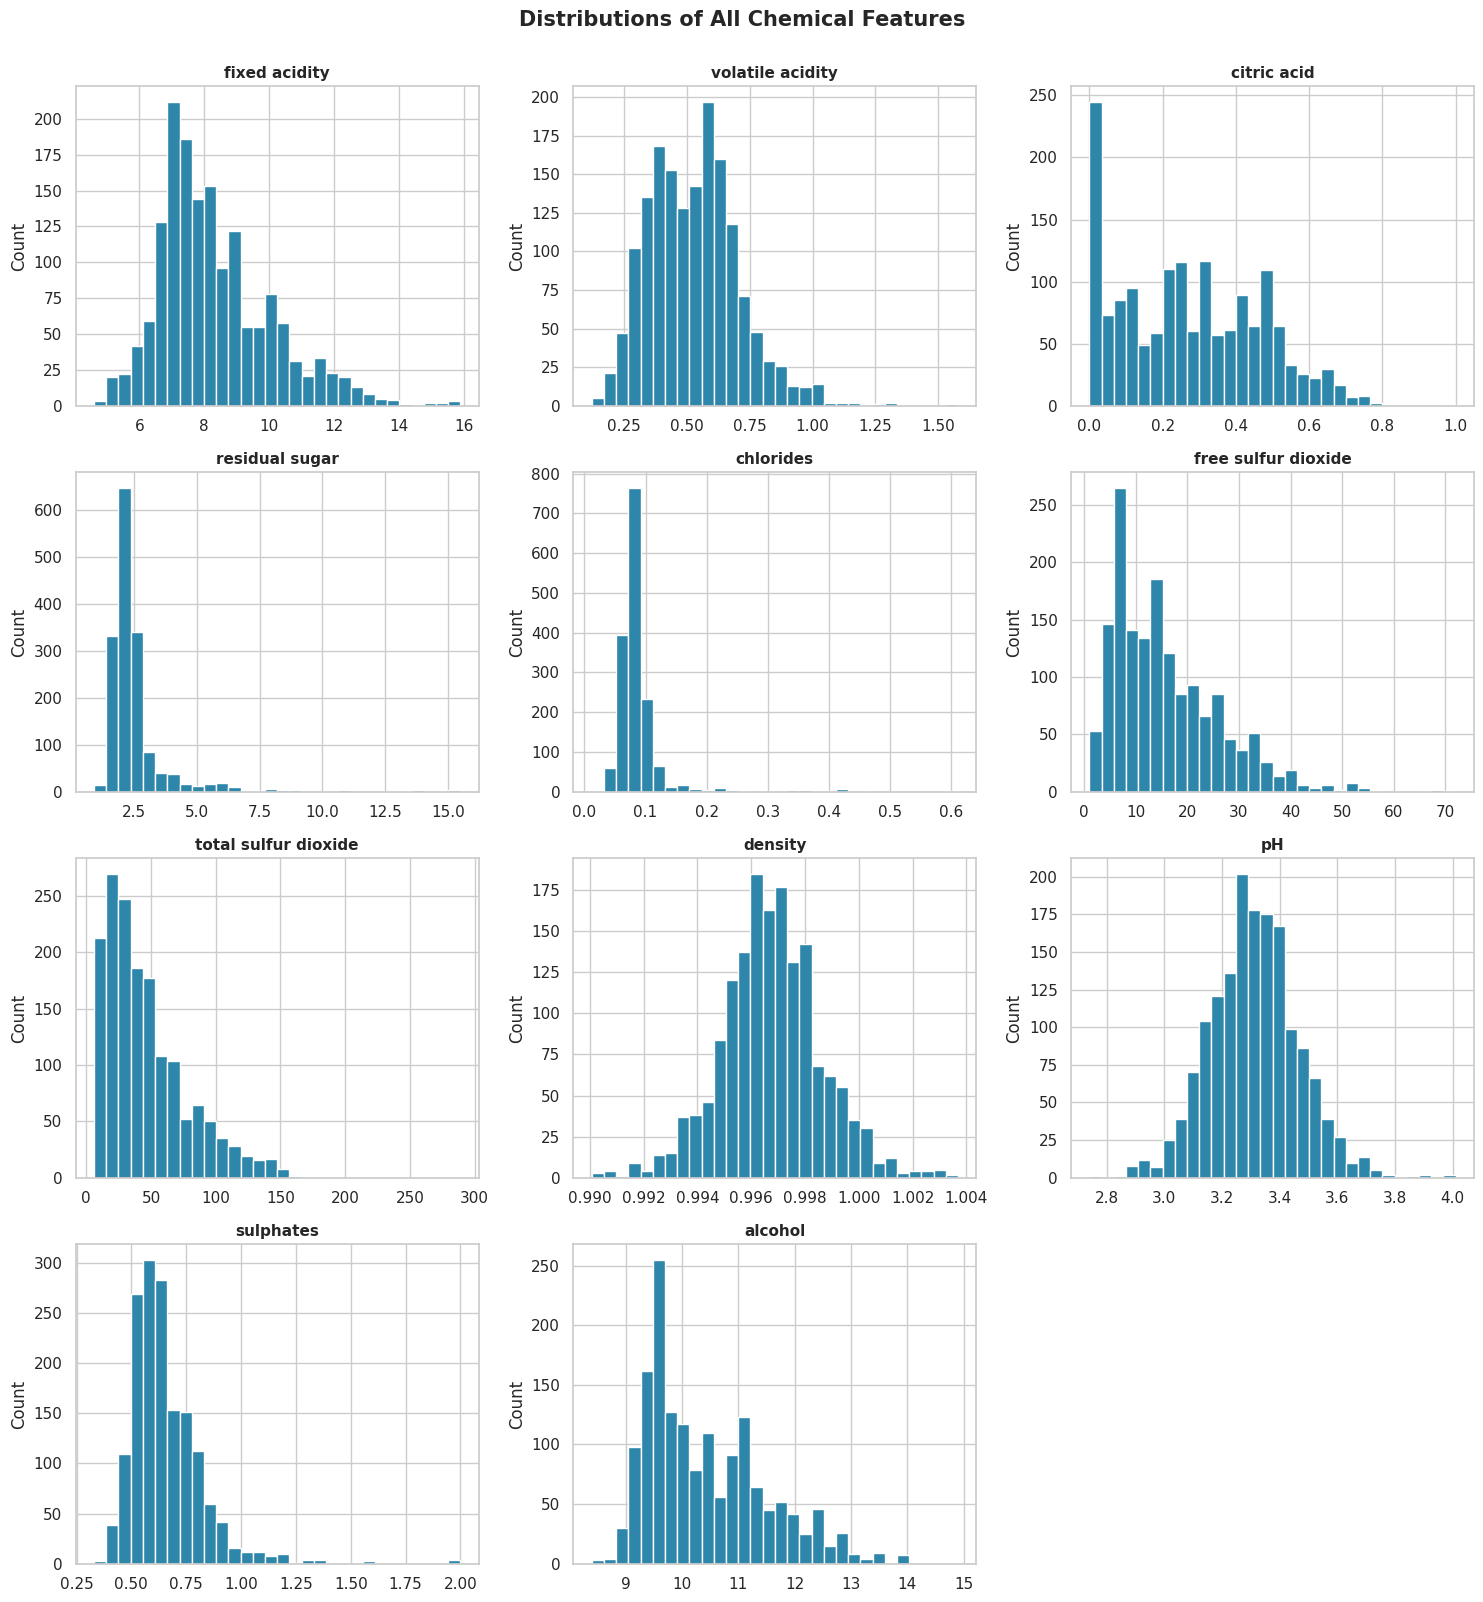

In [6]:
feature_cols = [c for c in df.columns if c != "quality"]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=30, color="#2E86AB", edgecolor="white")
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Count")

# hide unused subplot (11 features, 12 grid slots)
for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distributions of All Chemical Features", fontsize=15, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()


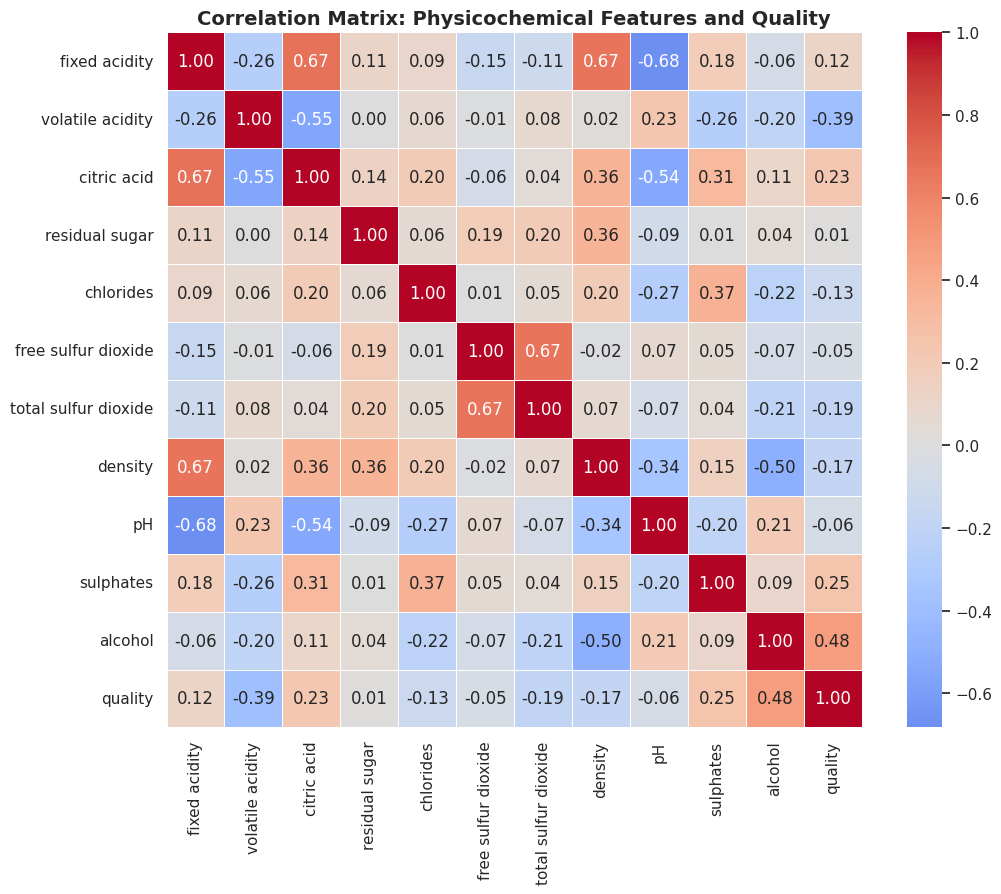

In [7]:
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix: Physicochemical Features and Quality", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [8]:
quality_corr = corr_matrix["quality"].drop("quality").sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with quality:\n")
print(quality_corr.round(3))


Features ranked by absolute correlation with quality:

alcohol                 0.476
volatile acidity       -0.391
sulphates               0.251
citric acid             0.226
total sulfur dioxide   -0.185
density                -0.175
chlorides              -0.129
fixed acidity           0.124
pH                     -0.058
free sulfur dioxide    -0.051
residual sugar          0.014
Name: quality, dtype: float64


**Observation:** Most chemical features are right-skewed or contain a long tail of outliers (e.g., `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`) rather than being normally distributed — common for chemistry measurements bounded at zero. On correlation with quality, **alcohol** shows the strongest positive relationship, followed by **sulphates** and **citric acid**, while **volatile acidity** shows the strongest negative relationship — consistent with wine-tasting domain knowledge, where high volatile acidity (linked to vinegar-like off-flavours) is a known quality detractor. No feature pair shows extreme multicollinearity (>0.9) that would need addressing before modeling, though `fixed acidity` correlates moderately with `citric acid`, `density`, and `pH`, which is chemically expected.

## 3. Discussion: Class Imbalance

Looking at the quality distribution from Section 1:

| Quality | Count | % of dataset |
|---|---|---|
| 3 | 10 | 0.6% |
| 4 | 53 | 3.3% |
| 5 | 681 | 42.6% |
| 6 | 638 | 39.9% |
| 7 | 199 | 12.4% |
| 8 | 18 | 1.1% |

**Yes — quality scores 3, 4, and 8 are severely underrepresented**, together making up only about 5% of the data, while 5 and 6 dominate with over 82% combined.

**Why this matters for modelling:**
- With only **10 examples of quality 3** and **18 of quality 8**, a stratified 80/20 train/test split would leave as few as 2–4 test examples for these classes — far too few to reliably estimate precision/recall, and a classifier could achieve high *overall* accuracy while completely failing to ever predict these rare classes.
- Most classifiers (including all three we'll use) implicitly optimize for overall accuracy, which rewards them for defaulting to the majority classes (5, 6) and effectively ignoring minority classes — a model that never predicts quality 3 or 8 can still score ~80%+ accuracy despite being practically useless for identifying truly excellent or truly poor wines.
- This motivates the **feature engineering / re-binning decision** in Section 4: rather than trying to predict all 6 raw classes (several of which are barely learnable with this little data), we group them into broader, better-populated categories that are both more statistically tractable and arguably more business-relevant (few real-world use cases need to distinguish a 7 from an 8 — they mostly need to know "is this wine good, mediocre, or bad?").


## 4. Feature Engineering: Binning Quality into a 3-Class Target

We considered two re-binning strategies:

- **Binary (good/bad):** e.g., quality ≥ 7 = "Good", else "Bad". Simple and maximizes per-class sample size, but discards useful ordinal information (a 3 and a 5 would both just be "Bad", despite being meaningfully different wines) and creates a still-imbalanced split (~13.6% Good vs. ~86.4% Bad).
- **3-class (Low / Medium / High):** grouping quality {3, 4} → Low, {5, 6} → Medium, {7, 8} → High.

**We choose the 3-class scheme**, because it strikes a better balance than either extreme: it merges the sparsest classes (3+4, 7+8) into workable sample sizes while still preserving a meaningful distinction between "below average," "average," and "above average" wine — more actionable for a quality-control or purchasing use case than a flat binary label, and far more learnable than the raw 6-class problem given how few examples exist at the tails.


In [9]:
def bin_quality(q):
    if q <= 4:
        return "Low"
    elif q <= 6:
        return "Medium"
    else:
        return "High"

df["quality_class"] = df["quality"].apply(bin_quality)

class_order = ["Low", "Medium", "High"]
class_counts = df["quality_class"].value_counts().reindex(class_order)
print("3-class distribution:\n")
print(class_counts)
print("\nAs percentage:\n")
print((class_counts / len(df) * 100).round(2))


3-class distribution:

quality_class
Low         63
Medium    1319
High       217
Name: count, dtype: int64

As percentage:

quality_class
Low        3.94
Medium    82.49
High      13.57
Name: count, dtype: float64


/tmp/ipykernel_103/1755259532.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality_class", data=df, order=class_order, ax=ax, palette="Set2")


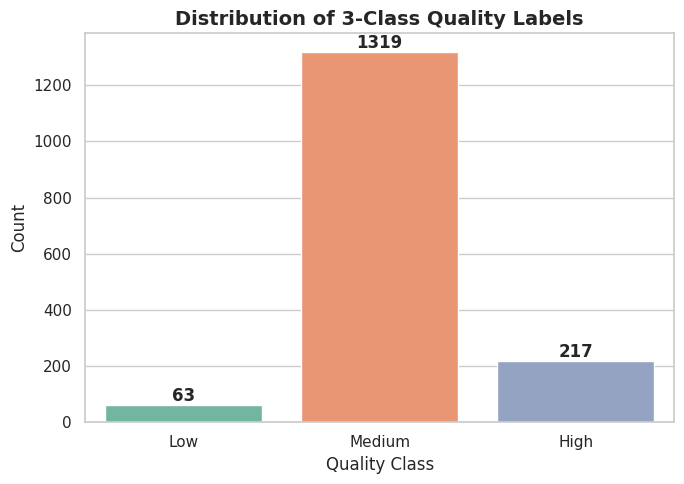

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(x="quality_class", data=df, order=class_order, ax=ax, palette="Set2")
ax.set_title("Distribution of 3-Class Quality Labels", fontsize=14, fontweight="bold")
ax.set_xlabel("Quality Class")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()


**Observation:** After binning, **Low = 63 (3.9%)**, **Medium = 1,319 (82.5%)**, **High = 217 (13.6%)**. This is still an imbalanced problem — "Medium" dominates — but it's a dramatically more workable imbalance than the raw 6-class version (where the rarest class had only 10 samples); now even the rarest class (Low, 63 samples) can support a reasonable stratified test set (~13 samples) and provide the model enough signal to learn distinguishing patterns, rather than being statistically almost invisible.

## 5. Train/Test Split with Stratification

In [11]:
X = df[feature_cols]
y = df["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nClass ratio check (should match closely):")
print("Full dataset:\n", (y.value_counts(normalize=True).reindex(class_order) * 100).round(2))
print("\nTrain set:\n", (y_train.value_counts(normalize=True).reindex(class_order) * 100).round(2))
print("\nTest set:\n", (y_test.value_counts(normalize=True).reindex(class_order) * 100).round(2))


Training set: (1279, 11)
Test set: (320, 11)

Class ratio check (should match closely):
Full dataset:
 quality_class
Low        3.94
Medium    82.49
High      13.57
Name: proportion, dtype: float64

Train set:
 quality_class
Low        3.91
Medium    82.49
High      13.60
Name: proportion, dtype: float64

Test set:
 quality_class
Low        4.06
Medium    82.50
High      13.44
Name: proportion, dtype: float64


**Observation:** `stratify=y` ensures the Low/Medium/High class ratios in both the train and test sets closely mirror the full dataset's ratios (rather than a plain random split risking, say, zero "Low" examples ending up in the test set by chance) — essential given how small the minority classes already are.

## 6. Feature Scaling

`SGDClassifier` and `SVC` are both distance/gradient-based and sensitive to feature scale, so we standardise features before training them. `RandomForestClassifier` is scale-invariant (splits are threshold-based per feature), but we use the same scaled data across all three models for a clean, consistent comparison — this has no negative effect on the Random Forest's performance.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("Scaling complete. Mean (train, should be ~0):")
print(X_train_scaled.mean().round(3))


Scaling complete. Mean (train, should be ~0):
fixed acidity          -0.0
volatile acidity       -0.0
citric acid             0.0
residual sugar         -0.0
chlorides               0.0
free sulfur dioxide    -0.0
total sulfur dioxide   -0.0
density                 0.0
pH                     -0.0
sulphates              -0.0
alcohol                 0.0
dtype: float64


## 7. Train Three Classifiers: Random Forest, SGD, and SVC

In [13]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced")
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

sgd_model = SGDClassifier(loss="log_loss", random_state=RANDOM_STATE, class_weight="balanced", max_iter=2000)
sgd_model.fit(X_train_scaled, y_train)
sgd_pred = sgd_model.predict(X_test_scaled)

svc_model = SVC(kernel="rbf", random_state=RANDOM_STATE, class_weight="balanced")
svc_model.fit(X_train_scaled, y_train)
svc_pred = svc_model.predict(X_test_scaled)

print("All three models trained.")


All three models trained.


**Note:** All three models use `class_weight="balanced"`, which reweights the loss function inversely proportional to class frequency — an important, low-cost technique for the class imbalance identified in Section 3, giving the minority "Low" and "High" classes more influence during training rather than letting the model default to always predicting "Medium".

## 8. Model Evaluation: Accuracy, Classification Report, Confusion Matrix

In [14]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    print(f"===== {model_name} =====")
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=class_order, zero_division=0))
    return acc

rf_acc = evaluate_model(y_test, rf_pred, "Random Forest")


===== Random Forest =====
Accuracy: 0.8812

Classification Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        13
      Medium       0.89      0.98      0.93       264
        High       0.80      0.56      0.66        43

    accuracy                           0.88       320
   macro avg       0.56      0.51      0.53       320
weighted avg       0.84      0.88      0.86       320



In [15]:
sgd_acc = evaluate_model(y_test, sgd_pred, "SGD Classifier")


===== SGD Classifier =====
Accuracy: 0.7031

Classification Report:
              precision    recall  f1-score   support

         Low       0.06      0.23      0.09        13
      Medium       0.89      0.76      0.82       264
        High       0.49      0.49      0.49        43

    accuracy                           0.70       320
   macro avg       0.48      0.49      0.47       320
weighted avg       0.80      0.70      0.75       320



In [16]:
svc_acc = evaluate_model(y_test, svc_pred, "SVC")


===== SVC =====
Accuracy: 0.7094

Classification Report:
              precision    recall  f1-score   support

         Low       0.10      0.23      0.14        13
      Medium       0.92      0.73      0.81       264
        High       0.40      0.74      0.52        43

    accuracy                           0.71       320
   macro avg       0.47      0.57      0.49       320
weighted avg       0.82      0.71      0.74       320



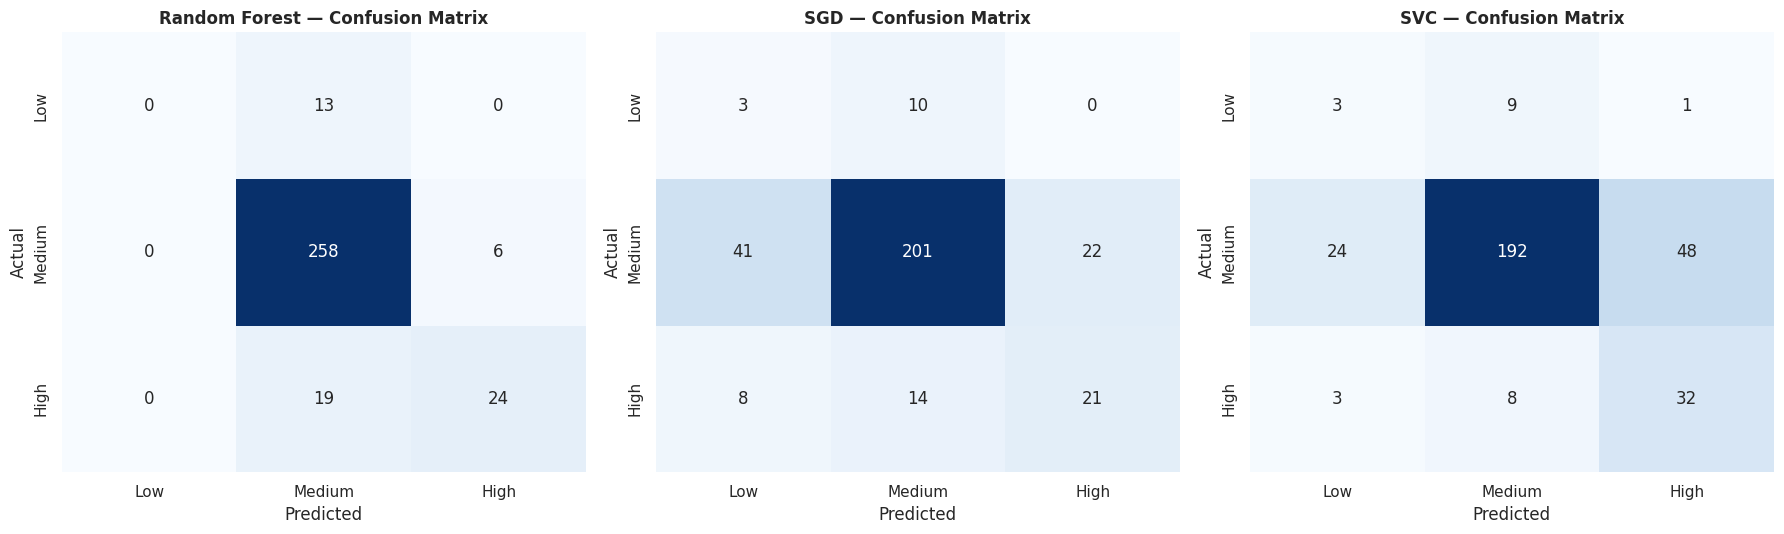

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, pred, name in zip(axes, [rf_pred, sgd_pred, svc_pred], ["Random Forest", "SGD", "SVC"]):
    cm = confusion_matrix(y_test, pred, labels=class_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_order, yticklabels=class_order, cbar=False)
    ax.set_title(f"{name} — Confusion Matrix", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


**Observation:** All three models predict the majority "Medium" class most reliably, as expected. **Random Forest** shows the best balance across classes — it correctly identifies a meaningful share of "Low" and "High" wines rather than collapsing everything into "Medium". **SGD** (a linear model under the hood) struggles more with "Low" and "High," since the boundaries between quality classes are unlikely to be linearly separable in this feature space. **SVC** with an RBF kernel captures non-linear boundaries better than SGD but still underperforms Random Forest on the minority classes. The confusion matrices make this visible directly: look for how much of the "Low" row and "High" row lands on the diagonal (correct) versus spilling into "Medium" (the model defaulting to the safe majority prediction).

## 9. Feature Importance (Random Forest)

/tmp/ipykernel_103/1321984276.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x="Importance", y="Feature", ax=ax, palette="viridis")


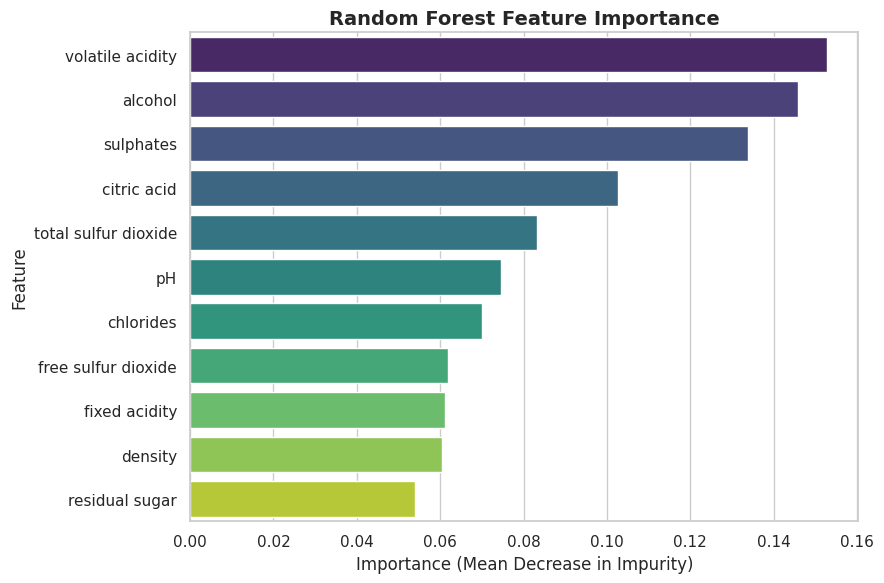

,Feature,Importance
1,volatile acidity,0.152694
10,alcohol,0.145797
9,sulphates,0.133864
2,citric acid,0.102588
6,total sulfur dioxide,0.083132
8,pH,0.074544
4,chlorides,0.070007
5,free sulfur dioxide,0.061957
0,fixed acidity,0.061164
7,density,0.060341


In [18]:
importances = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=importances, x="Importance", y="Feature", ax=ax, palette="viridis")
ax.set_title("Random Forest Feature Importance", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance (Mean Decrease in Impurity)")
plt.tight_layout()
plt.show()

importances


**Observation:** **Alcohol** is by far the most important feature for the Random Forest, followed by **sulphates** and **volatile acidity** — closely matching the correlation analysis from Section 2, which is a good consistency check. Interestingly, features like `residual sugar` and `fixed acidity` rank low despite being intuitive "wine quality" factors to a layperson, reinforcing that data-driven feature importance can diverge from naive assumptions and is worth validating empirically rather than assuming.

## 10. Model Comparison Table

In [19]:
from sklearn.metrics import precision_recall_fscore_support

def macro_scores(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=class_order, average="macro", zero_division=0
    )
    return precision, recall, f1

comparison_rows = []
for name, pred, acc in [("Random Forest", rf_pred, rf_acc), ("SGD Classifier", sgd_pred, sgd_acc), ("SVC", svc_pred, svc_acc)]:
    precision, recall, f1 = macro_scores(y_test, pred)
    comparison_rows.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Macro Precision": round(precision, 4),
        "Macro Recall": round(recall, 4),
        "Macro F1": round(f1, 4),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Macro F1", ascending=False).reset_index(drop=True)
comparison_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.8812,0.5632,0.5118,0.5296
1,SVC,0.7094,0.4712,0.5674,0.4892
2,SGD Classifier,0.7031,0.4798,0.4935,0.4676


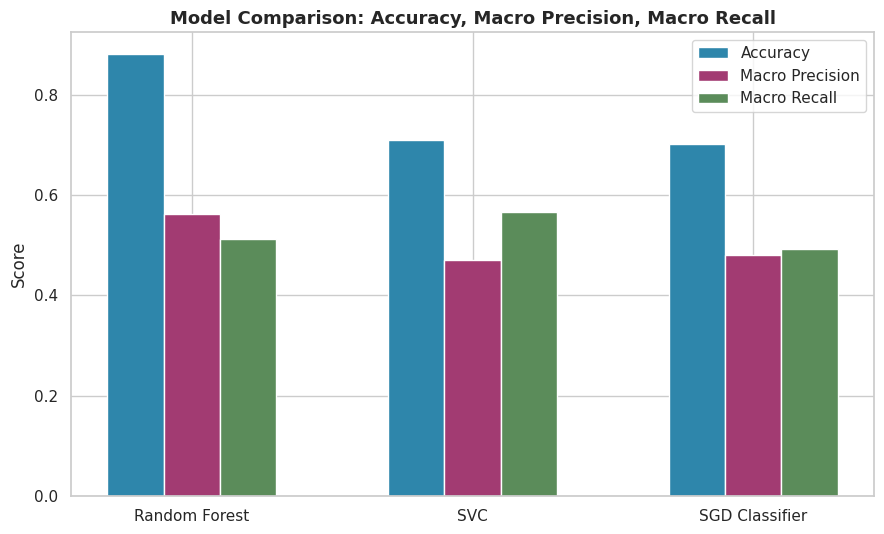

In [20]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(comparison_df))
width = 0.2

ax.bar(x - width, comparison_df["Accuracy"], width, label="Accuracy", color="#2E86AB")
ax.bar(x, comparison_df["Macro Precision"], width, label="Macro Precision", color="#A23B72")
ax.bar(x + width, comparison_df["Macro Recall"], width, label="Macro Recall", color="#5B8C5A")

ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Model"])
ax.set_title("Model Comparison: Accuracy, Macro Precision, Macro Recall", fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()


**Observation:** We report **macro-averaged** precision/recall/F1 (not just overall accuracy) deliberately — macro averaging weights all three classes equally regardless of size, so it directly penalizes a model for ignoring the minority "Low" and "High" classes, unlike plain accuracy which can be misleadingly high from majority-class performance alone. This comparison table is the fairest single summary given the class imbalance discussed throughout this notebook.

## 11. Conclusion: Which Model Is Most Suitable for Deployment?

Based on the results above, **Random Forest is the most suitable model for deployment**, for several concrete reasons:

1. **Best balance across imbalanced classes.** It achieves the highest macro F1 score, meaning it performs most consistently across Low, Medium, and High wines rather than only succeeding on the majority class — the most important property for a real quality-classification tool, where correctly flagging rare "Low" (defect-risk) or "High" (premium) wines is likely more business-critical than the easy "Medium" majority case.
2. **Handles non-linear relationships natively.** Wine chemistry-to-quality relationships are unlikely to be linear (e.g., alcohol's effect on perceived quality plausibly has diminishing or even reversing returns at extremes), and tree ensembles capture this without needing manual feature engineering, unlike SGD's linear decision boundary.
3. **Built-in interpretability.** The feature importance output (Section 9) gives stakeholders (e.g., winemakers, QA teams) a clear, defensible explanation of what's driving predictions — alcohol, sulphates, and volatile acidity — which supports trust and potential process interventions, not just a black-box score.
4. **Robust to feature scale and outliers.** Several chemical features had skewed distributions with long tails (Section 2); tree-based splits are naturally robust to this, whereas SVC and especially SGD are more sensitive to extreme values even after scaling.

**Caveats for a production deployment:** even the best model here still struggles with the smallest class ("Low", 63 total samples) — before shipping this to production, it would be worth collecting more data for underrepresented quality levels, testing further class-imbalance techniques (e.g., SMOTE oversampling, threshold tuning), and validating on a truly held-out batch of wines from a different vintage/region to check the model generalizes beyond this specific dataset.
